# Problem Statement

The objective of this project is to develop a machine learning-based classification system to detect Alzheimer’s disease from EEG signal features. By using algorithms such as XGBoost, the system aims to accurately distinguish between healthy individuals and Alzheimer’s patients, enabling early and scalable screening.

## 1. Importing libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import lightgbm as lgb
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Loading the dataset

In [5]:
DATA_PATH = "data/AD_all_patients.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Fp1,Fp2,F7,F3,Fz,F4,F8,T3,C3,Cz,C4,T4,T5,P3,Pz,P4,status
0,116.99375,41.09375,66.69375,-64.50625,-126.40625,8.39375,22.49375,42.19375,53.29375,4.49375,2.49375,73.79375,129.29375,0.09375,-124.90625,-245.50625,1
1,115.93125,38.63125,64.73125,-64.66875,-125.26875,8.73125,27.03125,43.23125,57.53125,11.13125,2.33125,72.23125,125.73125,-5.46875,-123.06875,-248.76875,1
2,115.72500,38.32500,66.02500,-62.67500,-135.37500,9.02500,29.42500,47.12500,49.92500,24.42500,1.22500,72.92500,123.22500,-3.07500,-129.97500,-246.27500,1
3,120.15625,40.75625,71.05625,-59.54375,-148.34375,12.15625,32.25625,49.05625,41.05625,12.75625,1.85625,73.55625,128.65625,-0.14375,-133.24375,-242.04375,1
4,119.50000,39.50000,71.30000,-59.20000,-125.50000,14.80000,28.50000,48.80000,42.20000,-1.20000,1.40000,70.30000,116.10000,3.40000,-129.00000,-240.90000,1


## 3. Dataset overview

In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nClass Distribution:")
print(df["status"].value_counts())

print("\nClass Distribution (Percentage):")
print(df["status"].value_counts(normalize=True) * 100)

Dataset Shape: (848640, 17)

Column Names:
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'T5', 'P3', 'Pz', 'P4', 'status']

Data Types:
Fp1       float64
Fp2       float64
F7        float64
F3        float64
Fz        float64
F4        float64
F8        float64
T3        float64
C3        float64
Cz        float64
C4        float64
T4        float64
T5        float64
P3        float64
Pz        float64
P4        float64
status      int64
dtype: object

Class Distribution:
status
1    512000
0    336640
Name: count, dtype: int64

Class Distribution (Percentage):
status
1    60.331825
0    39.668175
Name: proportion, dtype: float64


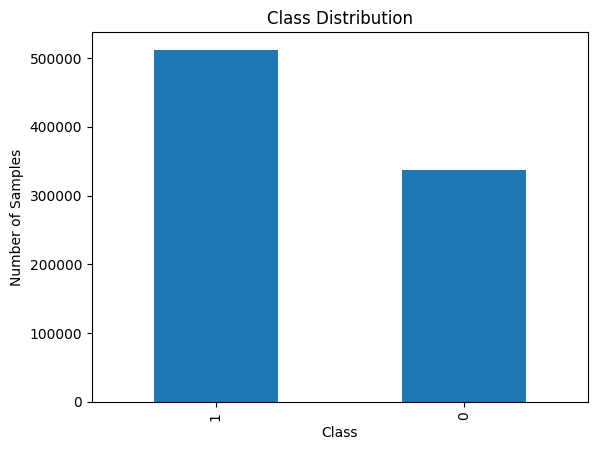

status
1    512000
0    336640
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt

y = df['status']
class_counts = y.value_counts()

plt.figure()
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

print(class_counts)

In [9]:
# Descriptive statistics
df.describe()

,Fp1,Fp2,F7,F3,Fz,F4,F8,T3,C3,Cz,C4,T4,T5,P3,Pz,P4,status
count,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.00000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000,848640.000000
mean,9.197634,23.204037,-11.428283,4.300583,-26.751948,-19.904077,-11.155309,-21.950993,18.05179,18.132288,16.903650,17.301845,-13.820743,-4.300905,39.719552,-37.499122,0.603318
std,107.877150,74.794207,60.968966,50.977283,77.433634,52.194458,147.858085,75.109347,36.53587,84.863804,65.831297,43.450596,63.844198,41.639673,59.709989,82.382886,0.489209
min,-698.175000,-555.575000,-334.400000,-460.775000,-434.975000,-572.075000,-1000.331250,-1006.575000,-465.37500,-163.743750,-451.425000,-451.675000,-726.368750,-487.075000,-385.775000,-646.412500,0.000000
25%,-25.956250,-10.381250,-38.181250,-19.387500,-42.243750,-39.475000,-22.768750,-55.868750,-2.60625,-11.087500,-9.300000,-4.918750,-29.018750,-21.412500,4.906250,-36.906250,0.000000
50%,-11.800000,2.256250,-7.100000,-1.056250,-13.931250,-18.025000,2.762500,-8.693750,12.91875,1.765625,7.187500,6.781250,-3.400000,-6.225000,24.062500,-12.568750,1.000000
75%,23.268750,35.487500,20.868750,19.387500,5.645313,7.362500,29.075000,13.743750,29.70000,24.175000,39.981250,23.875000,11.912500,11.425000,72.312500,4.425000,1.000000
max,7077.325000,376.937500,409.137500,638.925000,533.962500,227.187500,1152.418750,281.562500,346.96875,805.356250,343.512500,358.931250,244.687500,214.700000,595.250000,115.893750,1.000000


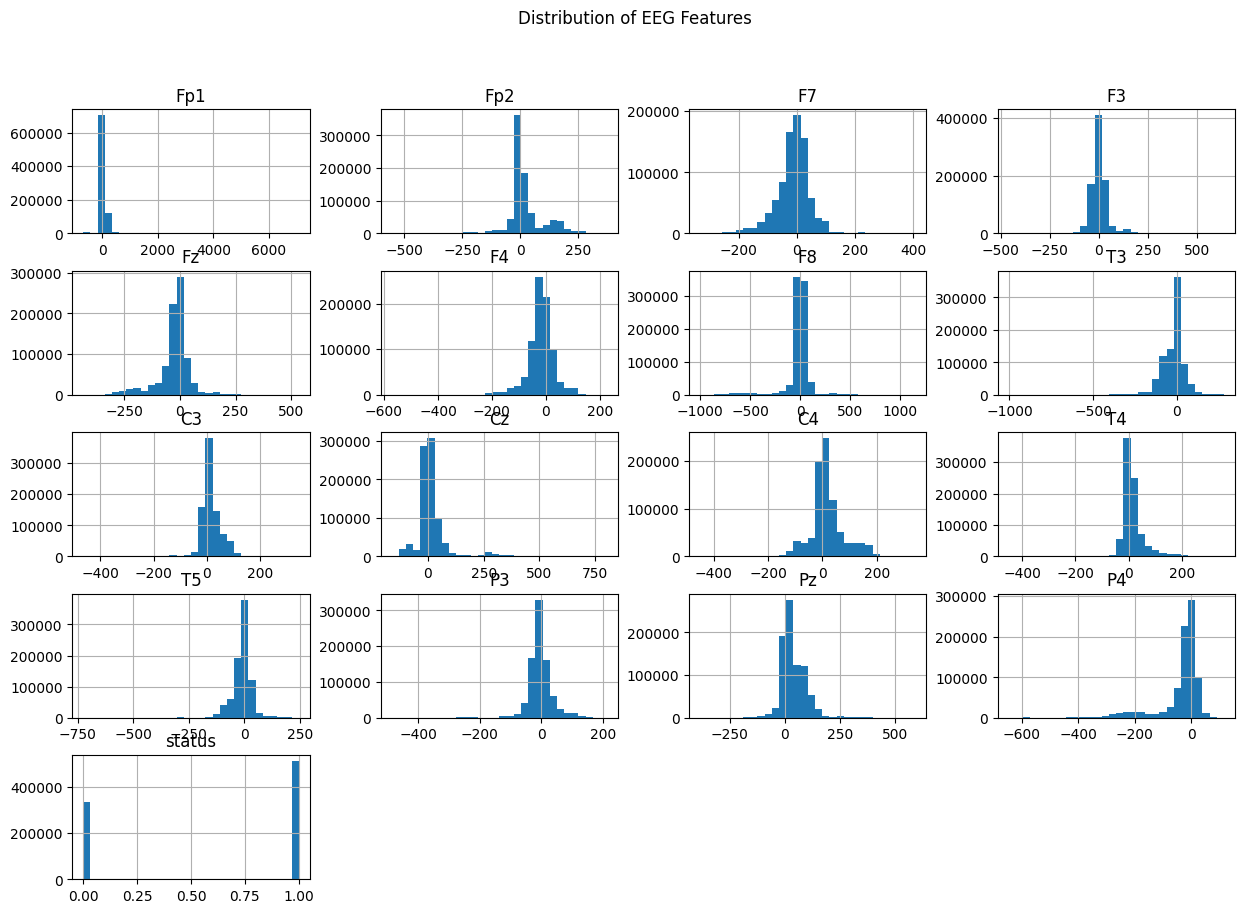

In [10]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10), bins=30)
plt.suptitle("Distribution of EEG Features")
plt.show()

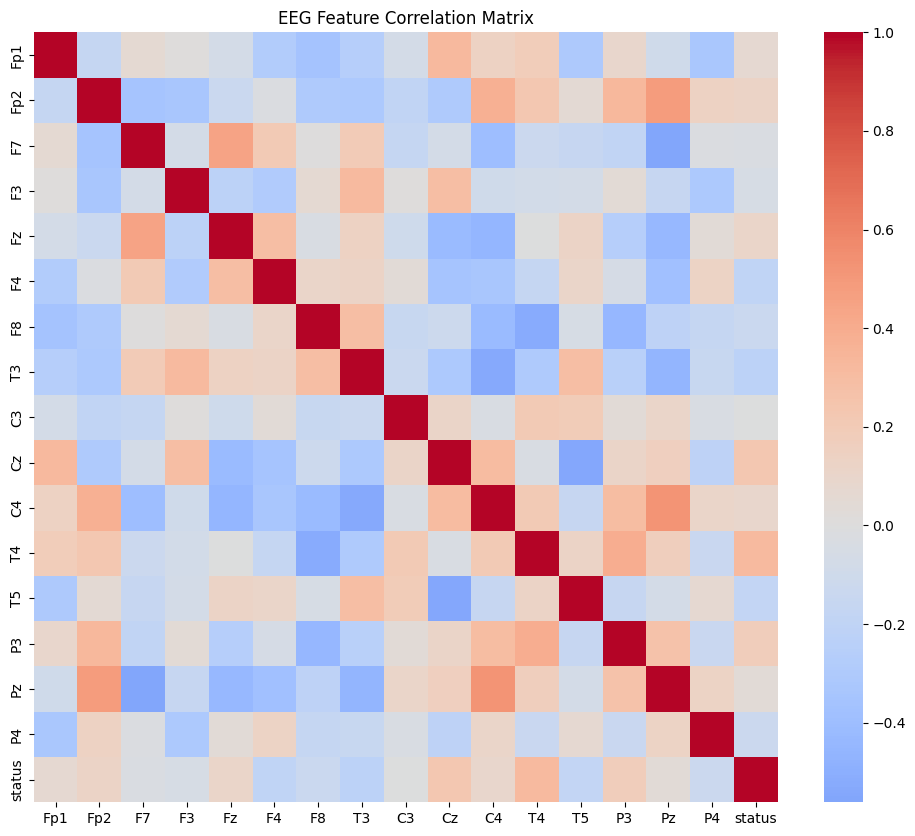

In [11]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("EEG Feature Correlation Matrix")
plt.show()

In [12]:
eeg_channels = df.columns.drop('status')

## 4. Dropping duplicate values

In [14]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 1036


In [15]:
print("Total null values in dataset:", df.isnull().sum().sum())

Total null values in dataset: 0


## 5. Feature engineering

In [17]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# =========================
# EEG CHANNELS
# =========================
eeg_cols = [
    'Fp1','Fp2','F7','F3','Fz','F4','F8',
    'T3','C3','Cz','C4','T4',
    'T5','P3','Pz','P4'
]

# Create feature dataframe
features = pd.DataFrame()

# =========================
# 1. GLOBAL STATISTICS
# =========================
features['mean'] = df[eeg_cols].mean(axis=1)
features['std'] = df[eeg_cols].std(axis=1)
features['var'] = df[eeg_cols].var(axis=1)
features['skew'] = df[eeg_cols].apply(skew, axis=1)
features['kurt'] = df[eeg_cols].apply(kurtosis, axis=1)
features['max'] = df[eeg_cols].max(axis=1)
features['min'] = df[eeg_cols].min(axis=1)
features['range'] = features['max'] - features['min']
features['rms'] = np.sqrt((df[eeg_cols]**2).mean(axis=1))

In [18]:
# =========================
# 2. DISPERSION FEATURES (FIXED)
# =========================

data = df[eeg_cols].values

# Percentiles (faster than pandas quantile)
q75 = np.percentile(data, 75, axis=1)
q25 = np.percentile(data, 25, axis=1)

features['iqr'] = q75 - q25

# Mean Absolute Deviation (manual implementation)
mean_ = data.mean(axis=1, keepdims=True)
features['mad'] = np.mean(np.abs(data - mean_), axis=1)

# Coefficient of variation
features['coeff_var'] = features['std'] / (features['mean'] + 1e-6)

In [19]:
# =========================
# 3. ENERGY FEATURES (OPTIMIZED)
# =========================

data = df[eeg_cols].values

energy = np.sum(data**2, axis=1)

features['energy'] = energy
features['log_energy'] = np.log(energy + 1e-6)

In [20]:

# =========================
# 4. HEMISPHERIC ASYMMETRY
# =========================
features['Fp_diff'] = df['Fp1'] - df['Fp2']
features['C_diff'] = df['C3'] - df['C4']
features['P_diff'] = df['P3'] - df['P4']

features['Fp_ratio'] = df['Fp1'] / (df['Fp2'] + 1e-6)
features['C_ratio'] = df['C3'] / (df['C4'] + 1e-6)

In [21]:
# =========================
# 5. REGIONAL FEATURES
# =========================
frontal = ['Fp1','Fp2','F3','F4','F7','F8','Fz']
central = ['C3','C4','Cz']
temporal = ['T3','T4','T5']
parietal = ['P3','P4','Pz']

features['frontal_mean'] = df[frontal].mean(axis=1)
features['central_mean'] = df[central].mean(axis=1)
features['temporal_mean'] = df[temporal].mean(axis=1)
features['parietal_mean'] = df[parietal].mean(axis=1)

features['frontal_std'] = df[frontal].std(axis=1)
features['central_std'] = df[central].std(axis=1)
features['temporal_std'] = df[temporal].std(axis=1)
features['parietal_std'] = df[parietal].std(axis=1)

In [22]:
# FINAL FEATURE MATRIX

X = pd.concat([df[eeg_cols], features], axis=1)

print("Total input features :", X.shape[1])
X.head()

Total input features : 43


,Fp1,Fp2,F7,F3,Fz,F4,F8,T3,C3,Cz,...,Fp_ratio,C_ratio,frontal_mean,central_mean,temporal_mean,parietal_mean,frontal_std,central_std,temporal_std,parietal_std
0,116.99375,41.09375,66.69375,-64.50625,-126.40625,8.39375,22.49375,42.19375,53.29375,4.49375,...,2.846996,21.370919,9.250893,20.093750,81.760417,-123.439583,81.589682,28.769428,44.093121,122.806569
1,115.93125,38.63125,64.73125,-64.66875,-125.26875,8.73125,27.03125,43.23125,57.53125,11.13125,...,3.000971,24.678274,9.302679,23.664583,80.397917,-125.768750,80.826990,29.657602,41.851922,121.672470
2,115.72500,38.32500,66.02500,-62.67500,-135.37500,9.02500,29.42500,47.12500,49.92500,24.42500,...,3.019569,40.755069,8.639286,25.191667,81.091667,-126.441667,83.566090,24.359050,38.701723,121.638494
3,120.15625,40.75625,71.05625,-59.54375,-148.34375,12.15625,32.25625,49.05625,41.05625,12.75625,...,2.948167,22.117833,9.784821,18.556250,83.756250,-125.143750,88.710159,20.233388,40.768493,121.153250
4,119.50000,39.50000,71.30000,-59.20000,-125.50000,14.80000,28.50000,48.80000,42.20000,-1.20000,...,3.025316,30.142836,12.700000,14.133333,78.400000,-122.166667,81.732633,24.341186,34.373391,122.293268


In [23]:
X.columns

Index(['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T3', 'C3', 'Cz', 'C4',
       'T4', 'T5', 'P3', 'Pz', 'P4', 'mean', 'std', 'var', 'skew', 'kurt',
       'max', 'min', 'range', 'rms', 'iqr', 'mad', 'coeff_var', 'energy',
       'log_energy', 'Fp_diff', 'C_diff', 'P_diff', 'Fp_ratio', 'C_ratio',
       'frontal_mean', 'central_mean', 'temporal_mean', 'parietal_mean',
       'frontal_std', 'central_std', 'temporal_std', 'parietal_std'],
      dtype='object')

## 6. Train-test split

In [25]:

from sklearn.model_selection import train_test_split

y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## 7. Outlier handling

In [27]:
X_train_clipped = X_train.copy()
X_test_clipped = X_test.copy()

for col in X_train.columns:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)

    X_train_clipped[col] = X_train[col].clip(lower, upper)
    X_test_clipped[col] = X_test[col].clip(lower, upper)

print("Outlier clipping done")

Outlier clipping done


## 8. Normalization

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_clipped),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_clipped),
    columns=X_test.columns,
    index=X_test.index
)

## 9. Data leakage check

In [31]:

print("\n--- DATA LEAKAGE CHECK ---")

overlap = set(X_train.index).intersection(set(X_test.index))
print("Overlap samples:", len(overlap))

print("Train mean:", X_train_scaled.mean().mean())
print("Test mean:", X_test_scaled.mean().mean())

print("Scaler fitted only on train ✔")


--- DATA LEAKAGE CHECK ---
Overlap samples: 0
Train mean: 0.40211204370381315
Test mean: 0.4022086483039122
Scaler fitted only on train ✔


## 10. Model comparision

In [33]:
# =========================
# IMPORTS
# =========================
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# =========================
# RANDOM SEED
# =========================
RANDOM_SEED = 42

# =========================
# MODELS
# =========================

######## ORIGINAL MODELS

# models = {
#     "XGBoost": XGBClassifier(
#         n_estimators=60,
#         max_depth=3,
#         learning_rate=0.04,
#         subsample=0.6,
#         colsample_bytree=0.6,
#         tree_method='hist',
#         eval_metric='logloss',
#         random_state=RANDOM_SEED
#     ),

#     "Random Forest": RandomForestClassifier(
#         n_estimators=50,          # baseline (not heavily tuned)
#         max_depth=3,
#         random_state=RANDOM_SEED,
#         n_jobs=-1
#     ),

#     "Logistic Regression": LogisticRegression(
#         max_iter=500,
#         random_state=RANDOM_SEED
#     )
# }

models = {
    "Logistic Regression": LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=500,
        random_state=RANDOM_SEED
    ),

    "Naive Bayes": GaussianNB(
        var_smoothing=1e-8  # only real hyperparameter
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion='gini',
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=RANDOM_SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "XGBoost":  XGBClassifier(
    n_estimators=50,      
    max_depth=3,            
    learning_rate=0.04,
    subsample=0.5,
    colsample_bytree=0.6,
    tree_method='hist',
    eval_metric='logloss',
    random_state=RANDOM_SEED
    )

}

# =========================
# CROSS VALIDATION SETUP
# =========================
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# =========================
# MODEL COMPARISON
# =========================
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_mean = cv_scores.mean()

    results.append({
        "Model": name,
        "Train Accuracy": round(train_acc * 100, 2),
        "Test Accuracy": round(test_acc * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1 Score": round(f1 * 100, 2),
        "CV Mean": round(cv_mean * 100, 2)
    })

# =========================
# FINAL TABLE
# =========================
df = pd.DataFrame(results)

# Pivot for PPT format
table = df.set_index("Model").T

print("\n=== FINAL MODEL COMPARISON TABLE ===\n")
print(table)


=== FINAL MODEL COMPARISON TABLE ===

Model           Logistic Regression  Naive Bayes  Decision Tree  \
Train Accuracy                91.68        61.97          78.77   
Test Accuracy                 91.63        61.86          78.65   
Precision                     93.75        86.91          90.22   
Recall                        92.27        43.28          72.46   
F1 Score                      93.01        57.78          80.37   
CV Mean                       91.57        61.97          78.74   

Model           Random Forest  XGBoost  
Train Accuracy          88.37    93.83  
Test Accuracy           88.43    93.77  
Precision               91.25    94.52  
Recall                  89.38    95.18  
F1 Score                90.31    94.85  
CV Mean                 88.03    93.77  


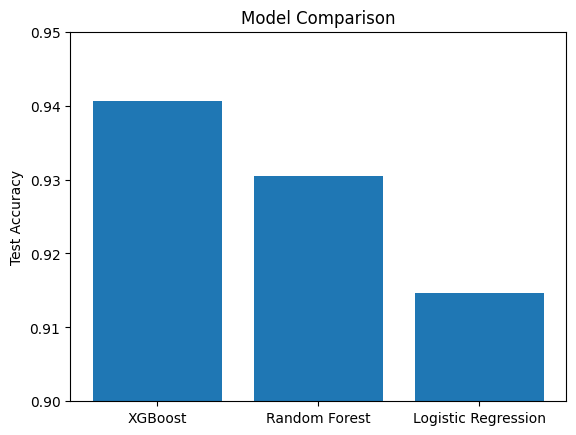

In [34]:
import matplotlib.pyplot as plt

models = ["XGBoost", "Random Forest", "Logistic Regression"]
test_acc = [0.940650, 0.930475, 0.914589]

plt.bar(models, test_acc)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison")
plt.ylim(0.9, 0.95)
plt.show()

## 11. Model selection and training

In [36]:
import time
from xgboost import XGBClassifier

# =========================
# MODEL DEFINITION
# =========================
final_model = XGBClassifier(
    n_estimators=50,        # ↓ fewer trees
    max_depth=3,            # ↓ simpler trees
    learning_rate=0.04,
    subsample=0.5,
    colsample_bytree=0.6,
    tree_method='hist',
    eval_metric='logloss',
    random_state=RANDOM_SEED
)

# =========================
# TRAINING + TIMING
# =========================
start_time = time.time()

final_model.fit(X_train_scaled, y_train)

end_time = time.time()
training_time = round(end_time - start_time, 2)

# =========================
# MODEL INFO
# =========================
model_info = {
    "algorithm": "XGBoost",
    "dataset_records": len(df),
    "num_features": X_train.shape[1],
    "train_samples": X_train.shape[0],
    "test_samples": X_test.shape[0],
    "training_time_seconds": training_time
}

print("Training Time:", training_time, "seconds")
print("\nModel Information:")
print(model_info)

Training Time: 4.06 seconds

Model Information:
{'algorithm': 'XGBoost', 'dataset_records': 5, 'num_features': 43, 'train_samples': 678083, 'test_samples': 169521, 'training_time_seconds': 4.06}


## 12. Model Evaluation

In [38]:
y_pred = final_model.predict(X_test_scaled)
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

y_train_pred = final_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Train Accuracy: 0.9383

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.92     67277
           1       0.95      0.95      0.95    102244

    accuracy                           0.94    169521
   macro avg       0.94      0.93      0.93    169521
weighted avg       0.94      0.94      0.94    169521



In [39]:
print("\nTest Metrics:\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))


Test Metrics:

Accuracy: 0.938
Precision: 0.945
Recall: 0.952
F1 Score: 0.948


In [40]:
# MISCLASSIFIED SAMPLES (CLEAN)

errors = X_test[y_test != y_pred].copy()

print("Total misclassified:", len(errors))

# Add labels
errors["Actual"] = y_test.loc[errors.index]
errors["Predicted"] = y_pred[y_test != y_pred]

# Round for readability
errors = errors.round(3)

# Show sample
errors.head()

Total misclassified: 10569


,Fp1,Fp2,F7,F3,Fz,F4,F8,T3,C3,Cz,...,frontal_mean,central_mean,temporal_mean,parietal_mean,frontal_std,central_std,temporal_std,parietal_std,Actual,Predicted
87552,12.706,-4.094,-6.794,0.306,-0.094,-10.194,-63.394,4.006,12.406,-15.894,...,-10.222,0.240,8.073,15.540,24.548,14.561,8.741,32.833,1,0
267401,5.400,-12.800,39.500,16.300,9.800,-45.100,9.300,-4.300,15.700,-15.000,...,3.200,4.467,-4.200,-7.733,26.343,16.925,10.050,22.287,0,1
87735,8.169,-2.931,-10.331,9.469,-9.831,12.569,-54.231,28.369,2.269,-22.431,...,-6.731,-7.431,11.269,11.869,22.914,13.175,14.854,23.168,1,0
821583,-9.212,-8.912,122.988,-5.112,-55.612,-5.612,-8.612,-33.712,27.088,40.488,...,4.273,14.821,-7.312,-17.479,55.358,33.528,25.035,5.719,1,0
310155,-24.019,3.681,33.781,13.581,0.581,-42.219,34.081,13.381,14.881,-17.319,...,2.781,-3.219,1.181,-4.452,28.303,16.468,11.262,4.259,1,0


## 13. CONFUSION MATRIX

TP: 97312, TN: 61640, FP: 5637, FN: 4932
Specificity: 0.9162
Sensitivity (Recall): 0.9518
MCC: 0.8696


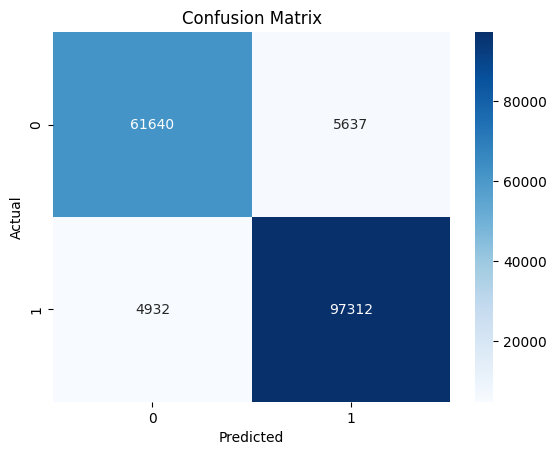

In [42]:
from sklearn.metrics import confusion_matrix, matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)
mcc = matthews_corrcoef(y_test, y_pred)

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"MCC: {mcc:.4f}")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 14. PROBABILITY DISTRIBUTION BY CLASS

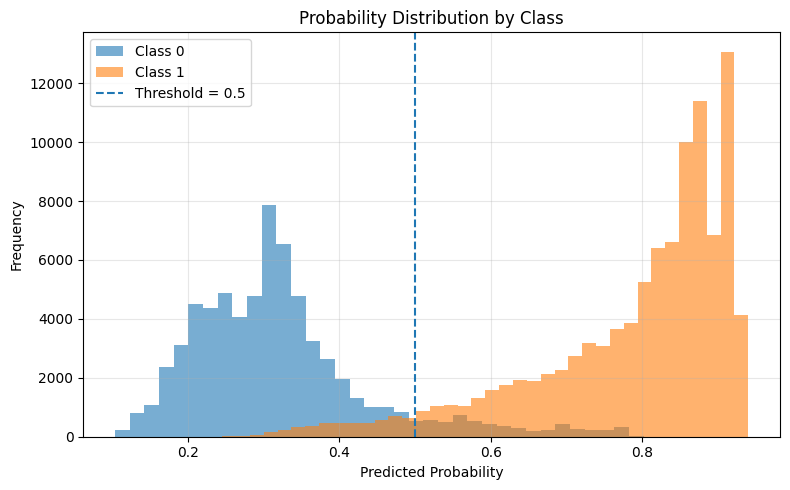

In [44]:
# =========================
# PROBABILITY DISTRIBUTION BY CLASS
# =========================
plt.figure(figsize=(8,5))

plt.hist(y_prob[y_test==0], bins=40, alpha=0.6, label='Class 0')
plt.hist(y_prob[y_test==1], bins=40, alpha=0.6, label='Class 1')

plt.axvline(0.5, linestyle='--', label='Threshold = 0.5')

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Probability Distribution by Class")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Threshold sensitivity analysis

In [46]:
# =========================
# THRESHOLD ANALYSIS (ACCURACY + RECALL)
# =========================
thresholds = np.arange(0.1, 1.01, 0.1)

rows = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)

    acc = accuracy_score(y_test, preds)
    recall = recall_score(y_test, preds)

    rows.append([t, acc, recall])

df_thr = pd.DataFrame(
    rows,
    columns=["Threshold", "Accuracy", "Recall"]
)

print(df_thr.round(3))

   Threshold  Accuracy  Recall
0        0.1     0.603   1.000
1        0.2     0.648   1.000
2        0.3     0.787   0.999
3        0.4     0.922   0.981
4        0.5     0.938   0.952
5        0.6     0.919   0.893
6        0.7     0.866   0.789
7        0.8     0.763   0.606
8        0.9     0.510   0.187
9        1.0     0.397   0.000


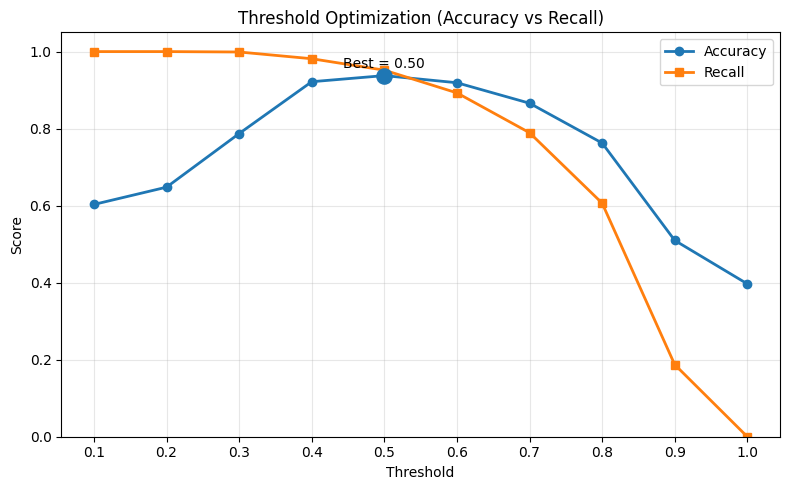

In [47]:
# =========================
# THRESHOLD PLOT (ACCURACY + RECALL)
# =========================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df_thr["Threshold"], df_thr["Accuracy"], marker='o', linewidth=2, label="Accuracy")
plt.plot(df_thr["Threshold"], df_thr["Recall"], marker='s', linewidth=2, label="Recall")

# Highlight best threshold (based on Accuracy OR Recall — choose one)
best_row = df_thr.loc[df_thr["Accuracy"].idxmax()]   # you can switch to Recall if needed
best_t = best_row["Threshold"]
best_val = best_row["Accuracy"]

plt.scatter(best_t, best_val, s=120, zorder=5)
plt.text(best_t, best_val + 0.02, f"Best = {best_t:.2f}", ha='center')

# Styling
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization (Accuracy vs Recall)")

plt.xticks(df_thr["Threshold"])
plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 16. ROC CURVE WITH AUC

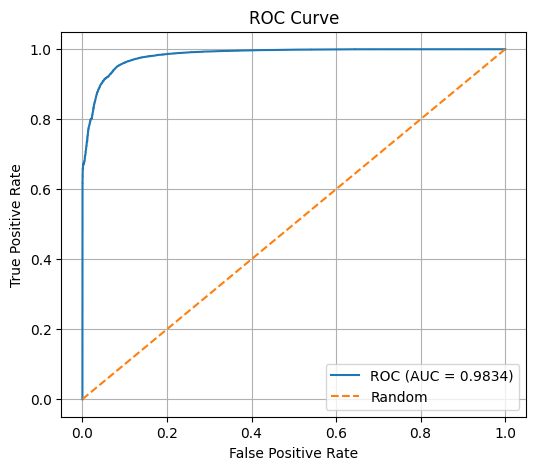

ROC-AUC Score: 0.9834496330949514


In [49]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC Score:", roc_auc)

## 17. PRECISION-RECALL CURVE

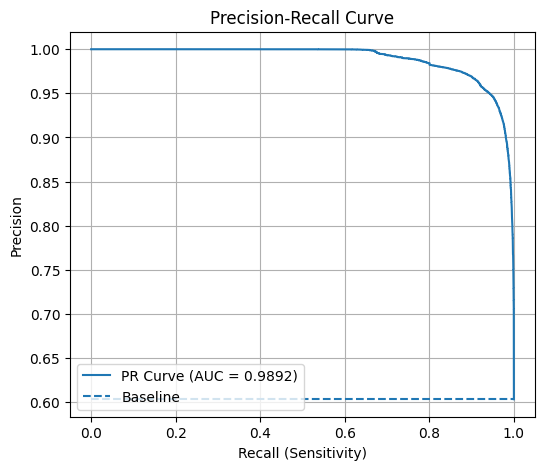

PR-AUC Score: 0.9891513971143675


In [51]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.4f})")

# Baseline (important)
baseline = sum(y_test) / len(y_test)
plt.hlines(baseline, 0, 1, linestyles='--', label="Baseline")

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

print("PR-AUC Score:", pr_auc)

## 18. FEATURE IMPORTANCE

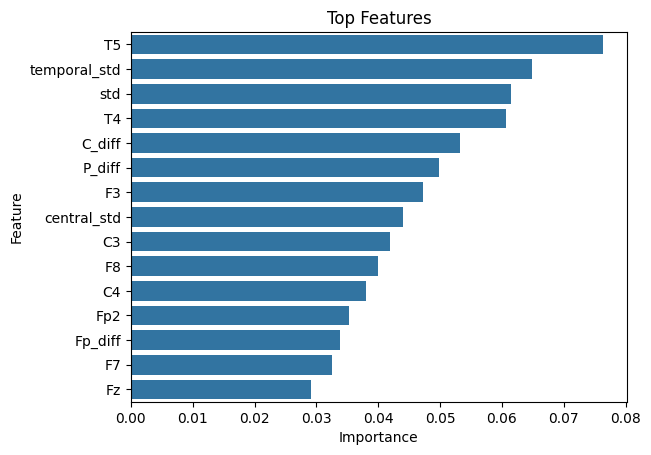

In [53]:

if hasattr(final_model, "feature_importances_"):
    importances = final_model.feature_importances_

    fi = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    sns.barplot(data=fi.head(15), x="Importance", y="Feature")
    plt.title("Top Features"); plt.show()


## 19. SHAP Plot

C:\Users\Asus\AppData\Local\Temp\ipykernel_18064\2561870363.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="dot")


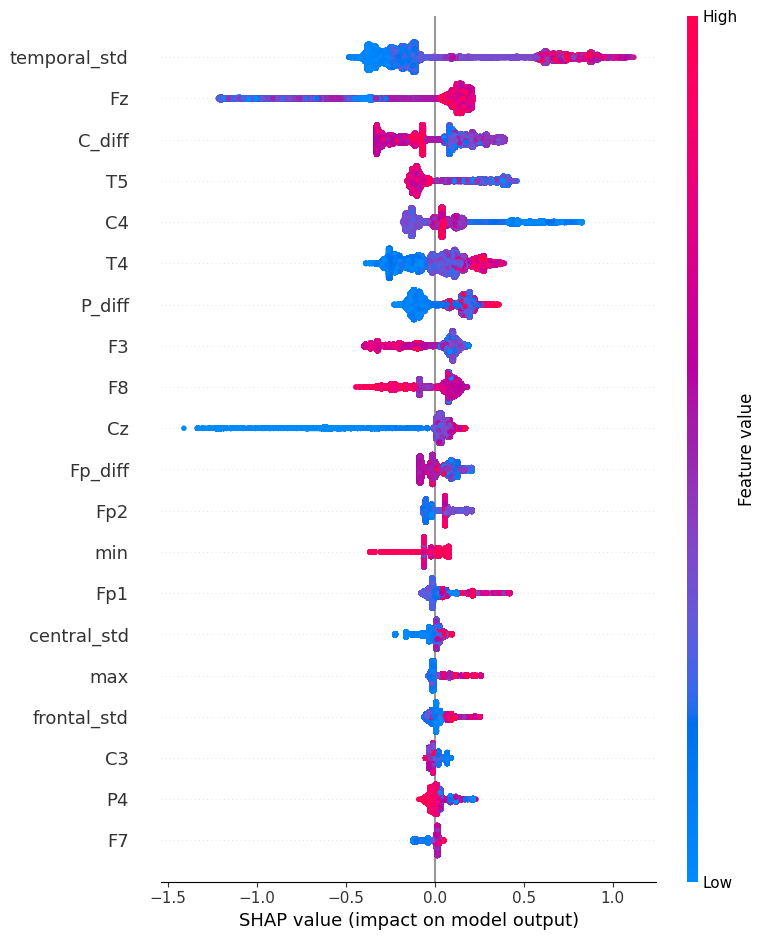

In [55]:
import shap

explainer = shap.TreeExplainer(final_model)

# compute on scaled (same as training)
shap_values = explainer.shap_values(X_test_scaled)
# plot with original features (readable)
shap.summary_plot(shap_values, X_test, plot_type="dot")

In [56]:
import psutil

process = psutil.Process()
memory_mb = process.memory_info().rss / (1024**2)

print(f"Memory used: {memory_mb:.2f} MB")

Memory used: 1469.68 MB


In [57]:
df.memory_usage(deep=True).sum() / (1024**2)

np.float64(0.00064849853515625)

In [58]:
X.memory_usage(deep=True).sum() / (1024**2)

np.float64(284.5350341796875)

In [59]:
df.memory_usage(deep=True)

Index             132
Model             308
Train Accuracy     40
Test Accuracy      40
Precision          40
Recall             40
F1 Score           40
CV Mean            40
dtype: int64

## 20. SAVING THE MODEL

In [61]:
import joblib

joblib.dump(final_model, "artifacts/model.joblib")
joblib.dump(scaler, "artifacts/scaler.joblib")

print("Saved successfully")

Saved successfully
